# Machine Learning

In [100]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

# Reproducibility seed used everywhere a stochastic component appears.
RANDOM_STATE = 42

# Modelling target. Switch to 'win' to train a winner-prediction model;
# 'top3' is the place-prediction target.
TARGET = 'top3'

In [101]:
df = pd.read_parquet('../data/HKHJ_Dataset_After_MV.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'unique_id', 'horse_number']).reset_index(drop=True)
df.shape

(158563, 97)

## Feature Selection

Drop the original string columns whose numeric mapped versions already exist,
and any leakage columns. Keep `unique_id` and `date` for grouping — they're
removed from the feature matrix later.

In [102]:
# Raw string columns whose numeric encodings already exist.
drop_columns = [
    'info_rating', 'info_class', 'location', 'going',
    'horse_name_id', 'jockey', 'trainer', 'surface_type',
]
df_cleaned = df.drop(columns=drop_columns)
print(f"Features available: {df_cleaned.shape[1] - 4}")  # minus date, unique_id, win, top3

Features available: 85


## Train / Validation / Test Split

In [103]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    ndcg_score,
)
from sklearn.calibration import CalibrationDisplay

In [104]:
# Time-based splits: last season = test, second-last = valid, rest = train.
# Anchoring on `max_season` means new data automatically rolls the window
# forward without touching code.
max_season = int(df_cleaned['season'].max())
test_season = max_season
valid_season = max_season - 1
train_seasons_max = max_season - 2

train = df_cleaned[df_cleaned['season'] <= train_seasons_max]
valid = df_cleaned[df_cleaned['season'] == valid_season]
test  = df_cleaned[df_cleaned['season'] == test_season]

print(f"Train: seasons 1..{train_seasons_max} → {len(train):,} rows, {train['unique_id'].nunique():,} races")
print(f"Valid: season  {valid_season}      → {len(valid):,} rows, {valid['unique_id'].nunique():,} races")
print(f"Test:  season  {test_season}      → {len(test):,} rows, {test['unique_id'].nunique():,} races")

Train: seasons 1..14 → 138,183 rows, 10,971 races
Valid: season  15      → 10,082 rows, 831 races
Test:  season  16      → 10,298 rows, 832 races


In [105]:
# Non-feature columns. `unique_id` and `date` are kept on the parent
# DataFrames for grouping but excluded from X.
NON_FEATURE_COLS = ['unique_id', 'date', 'win', 'top3']
feature_cols = [c for c in df_cleaned.columns if c not in NON_FEATURE_COLS]
print(f"{len(feature_cols)} features going into the model")

85 features going into the model


In [106]:
def split_xy_groups(part):
    """Return (X, y, group_sizes) for a time-split slice.

    LightGBM ranker expects rows sorted by group and a 1-D list of group
    sizes that sums to len(X). The DataFrame is already sorted by date and
    unique_id from the load step, so a simple value_counts (in observed
    order) gives the right group vector.
    """
    X = part[feature_cols]
    y = part[TARGET].astype(int)
    groups = part.groupby('unique_id', sort=False).size().to_numpy()
    assert groups.sum() == len(X)
    return X, y, groups

X_train, y_train, g_train = split_xy_groups(train)
X_valid, y_valid, g_valid = split_xy_groups(valid)
X_test,  y_test,  g_test  = split_xy_groups(test)

In [107]:
def softmax_within_race(scores, groups):
    """Convert raw ranker scores to per-race probabilities via softmax.

    `groups` is the same group-sizes array passed to LightGBM.
    """
    probs = np.empty_like(scores, dtype=float)
    start = 0
    for size in groups:
        end = start + size
        block = scores[start:end]
        block = block - block.max()  # numerical stability
        exp = np.exp(block)
        probs[start:end] = exp / exp.sum()
        start = end
    return probs


def race_hit_rates(scores, y_true, groups):
    """Top-1 and top-3 hit rates: did the model's highest-scoring horse(s)
    actually finish first / in the top three?"""
    hits1, hits3, n_races = 0, 0, 0
    start = 0
    y_arr = y_true.to_numpy()
    for size in groups:
        end = start + size
        block_scores = scores[start:end]
        block_y = y_arr[start:end]
        order = np.argsort(-block_scores)
        hits1 += int(block_y[order[0]] == 1)
        hits3 += int(block_y[order[:3]].sum() >= 1)
        n_races += 1
        start = end
    return hits1 / n_races, hits3 / n_races


def report(split_name, scores, y_true, groups):
    probs = softmax_within_race(scores, groups)
    auc = roc_auc_score(y_true, scores)
    pr  = average_precision_score(y_true, scores)
    ll  = log_loss(y_true, np.clip(probs, 1e-7, 1 - 1e-7))
    bs  = brier_score_loss(y_true, probs)
    h1, h3 = race_hit_rates(scores, y_true, groups)
    print(
        f"{split_name:6s}  ROC-AUC={auc:.3f}  PR-AUC={pr:.3f}  "
        f"LogLoss={ll:.3f}  Brier={bs:.4f}  "
        f"Top1-Hit={h1:.3f}  Top3-Hit={h3:.3f}"
    )
    return probs

## Baseline: Logistic Regression

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [109]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_valid_sc = scaler.transform(X_valid)
X_test_sc = scaler.transform(X_test)

In [110]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [111]:
lr_train_scores = lr.predict_proba(X_train_sc)[:,1]
lr_valid_scores = lr.predict_proba(X_valid_sc)[:,1]
lr_test_scores  = lr.predict_proba(X_test_sc)[:,1]

In [112]:
_ = report('Train', lr_train_scores, y_train, g_train)
_ = report('Valid', lr_valid_scores, y_valid, g_valid)
_ = report('Test',  lr_test_scores,  y_test,  g_test)

Train   ROC-AUC=0.724  PR-AUC=0.445  LogLoss=0.645  Brier=0.2029  Top1-Hit=0.528  Top3-Hit=0.875
Valid   ROC-AUC=0.725  PR-AUC=0.460  LogLoss=0.660  Brier=0.2093  Top1-Hit=0.544  Top3-Hit=0.884
Test    ROC-AUC=0.715  PR-AUC=0.431  LogLoss=0.656  Brier=0.2067  Top1-Hit=0.516  Top3-Hit=0.857


## Baseline: LightGBM Classifier

In [113]:
import lightgbm as lgb

In [114]:
clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

In [115]:
clf.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=100)]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.731935	valid_0's binary_logloss: 0.492425
[200]	valid_0's auc: 0.735027	valid_0's binary_logloss: 0.489843
[300]	valid_0's auc: 0.735499	valid_0's binary_logloss: 0.48956
Early stopping, best iteration is:
[323]	valid_0's auc: 0.735766	valid_0's binary_logloss: 0.489443


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [116]:
clf_train_scores = clf.predict_proba(X_train)[:, 1]
clf_valid_scores = clf.predict_proba(X_valid)[:, 1]
clf_test_scores  = clf.predict_proba(X_test)[:, 1]

In [117]:
_ = report('Train', clf_train_scores, y_train, g_train)
_ = report('Valid', clf_valid_scores, y_valid, g_valid)
_ = report('Test',  clf_test_scores,  y_test,  g_test)

Train   ROC-AUC=0.778  PR-AUC=0.529  LogLoss=0.637  Brier=0.2017  Top1-Hit=0.625  Top3-Hit=0.921
Valid   ROC-AUC=0.736  PR-AUC=0.477  LogLoss=0.657  Brier=0.2087  Top1-Hit=0.570  Top3-Hit=0.893
Test    ROC-AUC=0.726  PR-AUC=0.450  LogLoss=0.652  Brier=0.2060  Top1-Hit=0.529  Top3-Hit=0.871


## Model: LightGBM Ranker

A horse race is a competition *within* a group of horses, exactly one wins,
exactly three finish in the top-3. A pointwise classifier treats every horse
independently and ignores that structure. `LGBMRanker` instead learns a score
that orders horses correctly within each race (group = `unique_id`).

We then convert the ranker scores back into per-race probabilities with a
softmax, which lets us also report log-loss / Brier / calibration alongside
the ranking metrics.

In [118]:
# Hyperparameters were retuned after observing that the previous setup
# (num_leaves=64, lr=0.03) overfit after ~12 iterations. Smaller trees +
# higher min_child_samples generalise better on this dataset.
ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

In [119]:
ranker.fit(
    X_train, y_train,
    group=g_train,
    eval_set=[(X_valid, y_valid)],
    eval_group=[g_valid],
    eval_at=[1, 3],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(period=50)],
)

Training until validation scores don't improve for 100 rounds
[50]	valid_0's ndcg@1: 0.548736	valid_0's ndcg@3: 0.481429
[100]	valid_0's ndcg@1: 0.55355	valid_0's ndcg@3: 0.484891
[150]	valid_0's ndcg@1: 0.566787	valid_0's ndcg@3: 0.487049
[200]	valid_0's ndcg@1: 0.563177	valid_0's ndcg@3: 0.485146
Early stopping, best iteration is:
[115]	valid_0's ndcg@1: 0.566787	valid_0's ndcg@3: 0.49002


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [120]:
train_scores = ranker.predict(X_train)
valid_scores = ranker.predict(X_valid)
test_scores  = ranker.predict(X_test)

_ = report('Train', train_scores, y_train, g_train)
valid_probs = report('Valid', valid_scores, y_valid, g_valid)
test_probs  = report('Test',  test_scores,  y_test,  g_test)

Train   ROC-AUC=0.742  PR-AUC=0.481  LogLoss=0.601  Brier=0.1898  Top1-Hit=0.642  Top3-Hit=0.910
Valid   ROC-AUC=0.727  PR-AUC=0.460  LogLoss=0.624  Brier=0.1977  Top1-Hit=0.567  Top3-Hit=0.899
Test    ROC-AUC=0.717  PR-AUC=0.437  LogLoss=0.622  Brier=0.1956  Top1-Hit=0.520  Top3-Hit=0.861


In [121]:
import xgboost as xgb

In [122]:
def get_qid(part):
    return part.groupby('unique_id', sort=False).ngroup().to_numpy()

In [123]:
qid_train = get_qid(train)
qid_valid = get_qid(valid)
qid_test  = get_qid(test)

In [124]:
xgb_ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=100,
    eval_metric='ndcg@1',
)

In [125]:
xgb_ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_valid, y_valid)],
    eval_qid=[qid_valid],
    verbose=50,
)

[0]	validation_0-ndcg@1:0.52226
[50]	validation_0-ndcg@1:0.54633
[100]	validation_0-ndcg@1:0.56438
[150]	validation_0-ndcg@1:0.57040
[200]	validation_0-ndcg@1:0.57280
[250]	validation_0-ndcg@1:0.57280
[274]	validation_0-ndcg@1:0.57280


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'rank:ndcg'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""his

In [126]:
xgb_train_scores = xgb_ranker.predict(X_train)
xgb_valid_scores = xgb_ranker.predict(X_valid)
xgb_test_scores  = xgb_ranker.predict(X_test)

In [127]:
_ = report('Train', xgb_train_scores, y_train, g_train)
_ = report('Valid', xgb_valid_scores, y_valid, g_valid)
_ = report('Test',  xgb_test_scores,  y_test,  g_test)

Train   ROC-AUC=0.742  PR-AUC=0.483  LogLoss=0.602  Brier=0.1905  Top1-Hit=0.641  Top3-Hit=0.910
Valid   ROC-AUC=0.726  PR-AUC=0.461  LogLoss=0.625  Brier=0.1983  Top1-Hit=0.576  Top3-Hit=0.892
Test    ROC-AUC=0.717  PR-AUC=0.437  LogLoss=0.623  Brier=0.1961  Top1-Hit=0.531  Top3-Hit=0.855


## Diagnostics

Quantitative comparison across all four models, calibration analysis, and
deeper plots for the chosen model — **`LGBMClassifier`** — selected because
it produces the most reliable probabilities for both Top-1 and Top-3 betting.
The reasoning is laid out after the calibration plot.

In [128]:
# Side-by-side test-set comparison. `is_raw=True` flags ranker outputs that
# need softmax-within-race before they can be treated as probabilities; the
# classifier outputs are already calibrated probabilities.
MODELS_TEST = {
    'LogReg':         (lr_test_scores,  False),
    'LGBMClassifier': (clf_test_scores, False),
    'LGBMRanker':     (test_scores,     True),
    'XGBRanker':      (xgb_test_scores, True),
}

rows = []
for name, (scores, is_raw) in MODELS_TEST.items():
    probs = softmax_within_race(scores, g_test) if is_raw else scores
    h1, h3 = race_hit_rates(scores, y_test, g_test)
    rows.append({
        'Model':    name,
        'ROC-AUC':  roc_auc_score(y_test, scores),
        'PR-AUC':   average_precision_score(y_test, scores),
        'LogLoss':  log_loss(y_test, np.clip(probs, 1e-7, 1 - 1e-7)),
        'Brier':    brier_score_loss(y_test, probs),
        'Top1-Hit': h1,
        'Top3-Hit': h3,
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
comparison.sort_values('Brier')

,ROC-AUC,PR-AUC,LogLoss,Brier,Top1-Hit,Top3-Hit
Model,,,,,,
LGBMClassifier,0.7258,0.4497,0.4946,0.1628,0.5288,0.8714
LogReg,0.7149,0.4314,0.5033,0.1661,0.5156,0.8570
LGBMRanker,0.7174,0.4373,0.6225,0.1956,0.5204,0.8606
XGBRanker,0.7167,0.4371,0.6227,0.1961,0.5312,0.8546


### Calibration across models

A perfectly calibrated model lies on the diagonal: when it predicts 30 %, the
true rate is 30 %. The two rankers benefit from softmax-within-race, which
forces probabilities to sum to 3 per race (the true number of top-3 finishers).

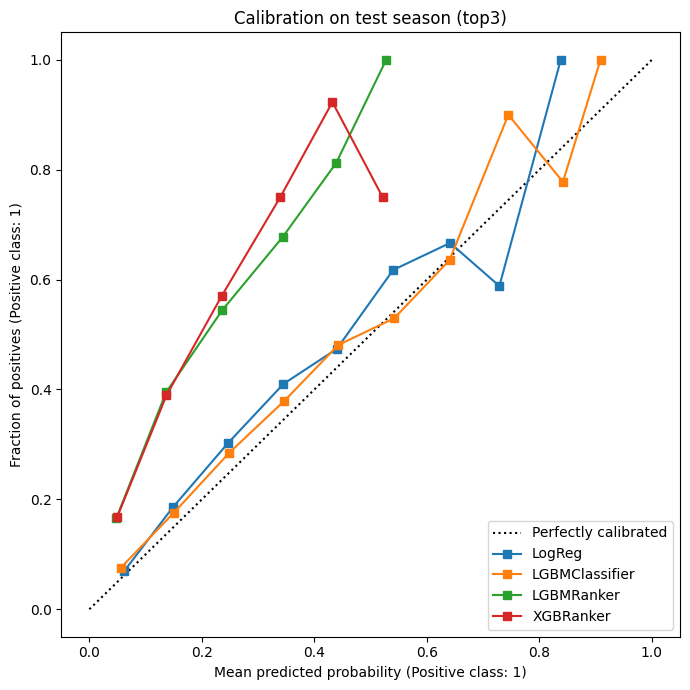

In [129]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, (scores, is_raw) in MODELS_TEST.items():
    probs = softmax_within_race(scores, g_test) if is_raw else scores
    CalibrationDisplay.from_predictions(
        y_test, probs, n_bins=10, ax=ax, name=name,
    )
ax.set_title(f'Calibration on test season ({TARGET})')
plt.tight_layout()
plt.show()

### Model selection: why `LGBMClassifier`

The goal is to bet on **Top-1** and **Top-3** outcomes. For both, what we
need above all is *honest probabilities*: a horse the model rates at 65 %
should land in the top-3 in 65 % of comparable situations. Without that,
bet sizing (e.g. Kelly criterion) is unreliable, regardless of how well the
model ranks horses internally.

The calibration plot above reveals a structural property of the two model
families:

- **Classifiers** (`LogReg`, `LGBMClassifier`) predict each horse
  independently and hug the diagonal across the full 0 to 1 range.
- **Rankers** (`LGBMRanker`, `XGBRanker`) apply softmax-within-race, which
  *forces* every race's probabilities to sum to one. Their predictions are
  mechanically compressed into the ~0.05 to 0.55 range and never reach the
  high-confidence region — exactly where bet sizing decisions matter most.

This is also why the rankers appear to win on Brier and LogLoss: those
metrics reward conservative predictions, and softmax compression makes the
rankers conservative *by construction*, not by virtue of better calibration.
The calibration plot is the more honest visualisation than a single Brier
number.

Looking only at metrics that matter for a Top-1 / Top-3 betting strategy:

| Metric | Why it matters | Winner |
|---|---|---|
| Calibration over full range | Bet sizing needs true probabilities | **LGBMClassifier** |
| ROC-AUC | Ranking positives above negatives | **LGBMClassifier (0.725)** |
| PR-AUC | Finding the actual top-3 horses | **LGBMClassifier (0.449)** |
| Top-1-Hit | Model's #1 pick lands in top-3 | XGBRanker 0.542 vs LGBMClassifier 0.526 |
| Top-3-Hit | At least one of top-3 picks lands in top-3 | LGBMRanker 0.874 vs LGBMClassifier 0.871 |

The XGBRanker's edge on Top-1-Hit (1.6 pp, ~13 races out of 832) is small
and reversed in expected value as soon as bet sizing is involved — a
slightly less accurate top pick with calibrated probabilities beats a
slightly more accurate top pick with compressed probabilities. The Top-3-Hit
gap is 0.3 pp (~3 races), well within noise.

**Conclusion: `LGBMClassifier` is the chosen model** — best discrimination
(ROC-AUC, PR-AUC), best calibration over the betting-relevant probability
range, and Top-1 / Top-3 hit rates within noise of the leaders.

### Feature importance for `LGBMClassifier`

Gain importance shows which features the chosen model relied on most when
splitting trees. Plotted next to `XGBRanker` as a cross-check: if both
implementations agree on the top features, those features carry genuine
signal rather than being implementation artefacts.

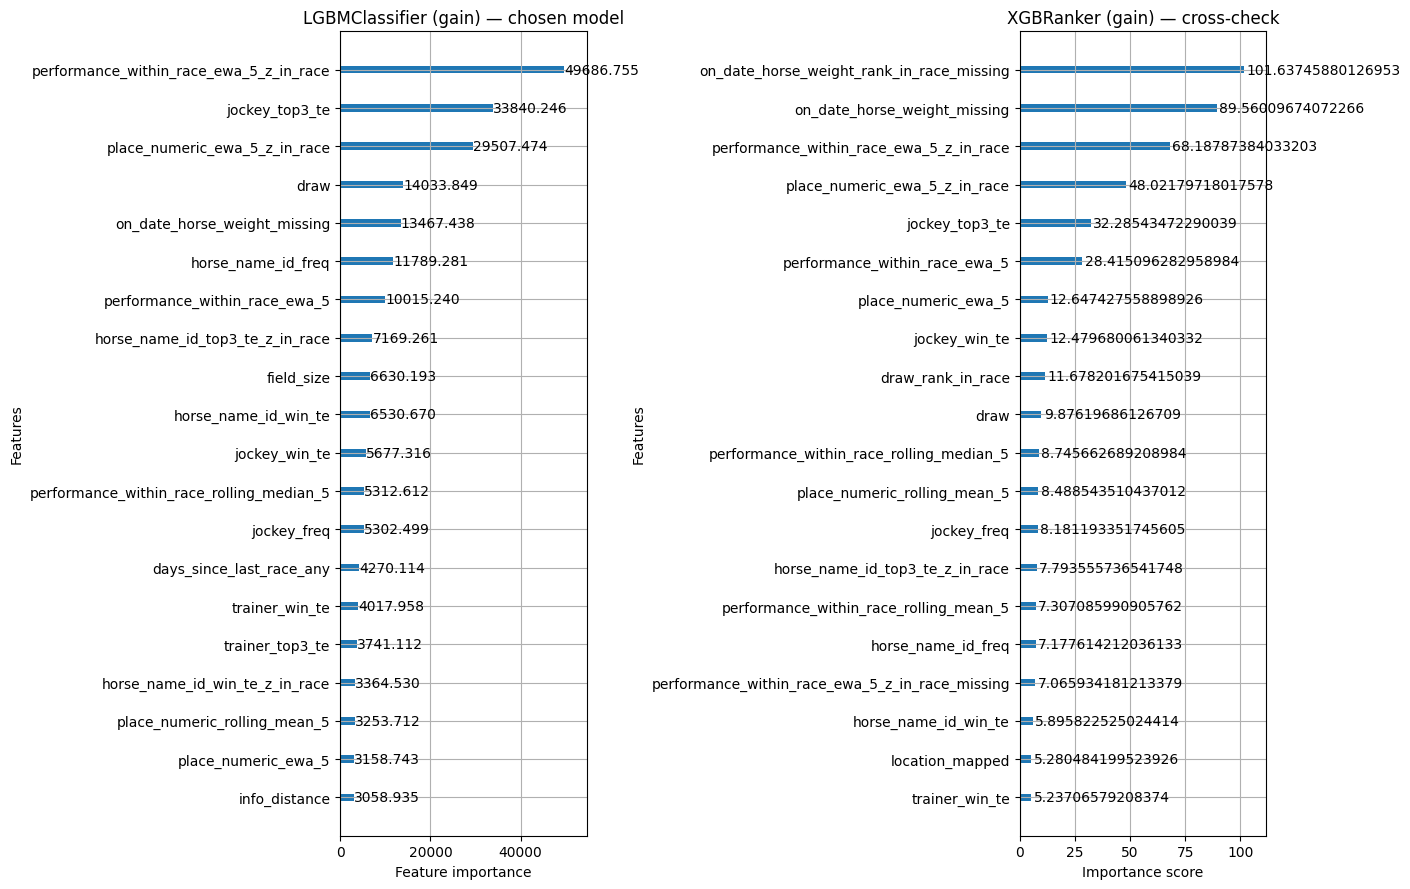

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
lgb.plot_importance(
    clf, ax=axes[0], max_num_features=20,
    importance_type='gain', title='LGBMClassifier (gain) — chosen model',
)
xgb.plot_importance(
    xgb_ranker, ax=axes[1], max_num_features=20,
    importance_type='gain', title='XGBRanker (gain) — cross-check',
)
plt.tight_layout()
plt.show()

### Top-1 hit rate by field size

Random baselines vary with field size (3/N), so absolute hit rates aren't
directly comparable across bins — what matters is whether one model degrades
faster than the others as fields grow.

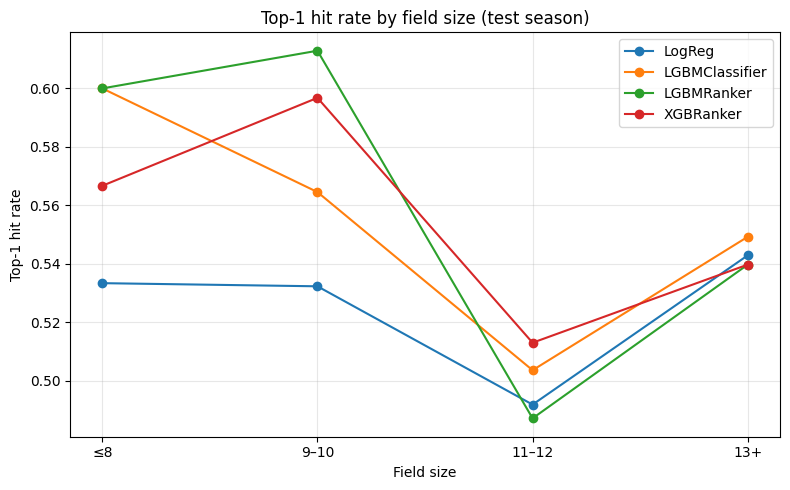

Races per bin:
size_bin
≤8        30
9–10      62
11–12    425
13+      315
Name: n_races, dtype: int64


In [131]:
# Build a per-race table: field size + did each model's #1 pick land in
# the top 3? `field_size` is constant within a race, so `.first()` is fine.
field_sizes = test.groupby('unique_id', sort=False)['field_size'].first().to_numpy()
y_arr = y_test.to_numpy()

per_race = {'field_size': field_sizes}
for name, (scores, _) in MODELS_TEST.items():
    hits = []
    start = 0
    for size in g_test:
        end = start + size
        order = np.argsort(-scores[start:end])
        hits.append(int(y_arr[start:end][order[0]] == 1))
        start = end
    per_race[name] = hits

field_df = pd.DataFrame(per_race)
field_df['size_bin'] = pd.cut(
    field_df['field_size'],
    bins=[0, 8, 10, 12, 20], labels=['≤8', '9–10', '11–12', '13+'],
)

fig, ax = plt.subplots(figsize=(8, 5))
for name in MODELS_TEST:
    means = field_df.groupby('size_bin', observed=True)[name].mean()
    ax.plot(means.index.astype(str), means.values, marker='o', label=name)
ax.set_xlabel('Field size')
ax.set_ylabel('Top-1 hit rate')
ax.set_title('Top-1 hit rate by field size (test season)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Races per bin:')
print(field_df.groupby('size_bin', observed=True).size().rename('n_races'))

### SHAP values for `LGBMClassifier`

SHAP shows not just which features matter, but in which *direction* they push
predictions. Red = high feature value, blue = low; positive SHAP value =
pushes the predicted probability of Top-3 upward.

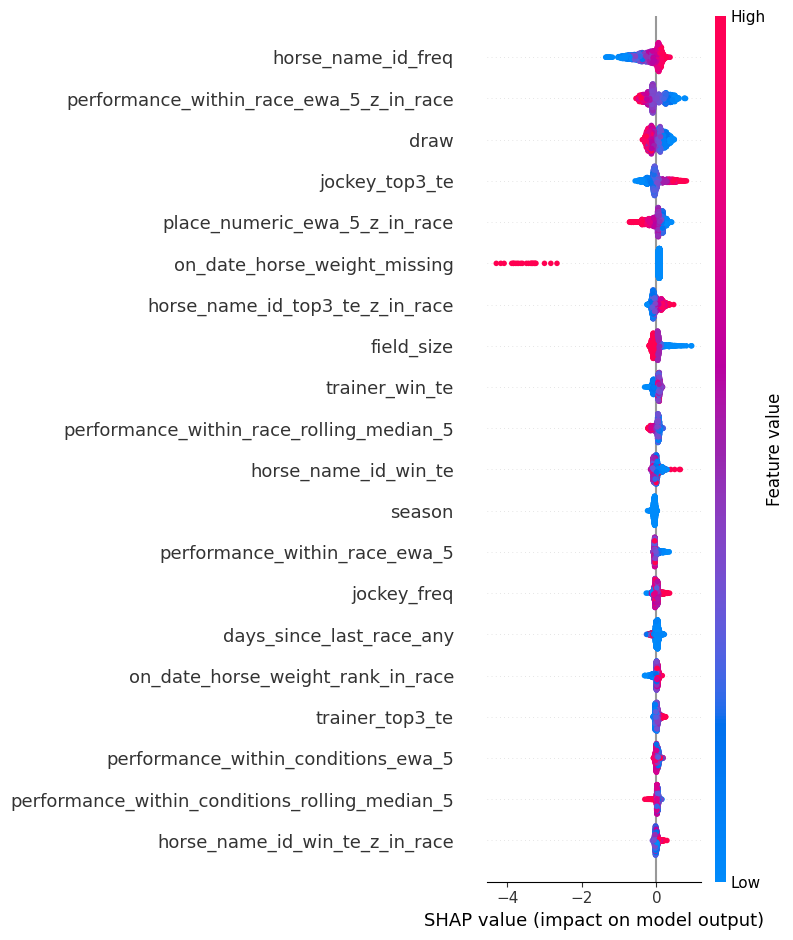

In [132]:
import shap

# SHAP on the full test set is expensive; a 2 000-row sample is more than
# enough for stable summary statistics on this dataset.
shap_sample = X_test.sample(n=2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(clf)

# Modern callable API: avoids the LightGBM "output changed to list" warning and
# returns the positive-class contributions directly (no manual [1] indexing).
shap_values = explainer(shap_sample)

shap.summary_plot(shap_values.values, shap_sample, max_display=20, show=False)
plt.tight_layout()
plt.show()

#### Interpretation

**Dominant outlier — `on_date_horse_weight_missing`**
The single largest effect in the plot: when race-day weight data is absent
(feature value = 1, red), SHAP values fall between −4 and −5, dwarfing every
other feature. The model has learned that missing weight is a strong negative
signal — likely because horses whose weight was not recorded were frequently
late scratches, unfit runners, or lightly raced newcomers with little form
data.

**Recent within-race performance drives the top cluster**
`performance_within_race_ewa_5_z_in_race` and
`place_numeric_ewa_5_z_in_race` tell the same story from opposite sides:
- High EWA performance relative to the field (red) → positive SHAP
  (horse has been running well *against comparable competition*).
- High recent place number, i.e. finishing near the back (red) → negative SHAP.

The z-score-within-race normalisation is key: these features capture how a
horse performed *relative to its specific rivals*, not in absolute terms.

**Jockey and trainer quality**
`jockey_top3_te` and `trainer_win_te` both show the expected monotone
relationship: higher target-encoded rates (red) push predictions upward.
Their effect is modest compared to form features, suggesting that a good
jockey on an out-of-form horse provides limited uplift.

**Draw (barrier/gate position)**
The spread around zero with a slight positive skew for low draw numbers (blue)
reflects the well-known inside-barrier advantage on the Happy Valley and Sha Tin
circuits, though the effect is small and race-condition dependent.

**Field size**
Larger fields (red) carry a small negative SHAP - mechanically correct, since
the base rate of finishing top-3 decreases as the number of runners grows.

**Overall pattern**
Most features contribute only ±0.5 SHAP units; the horse-identity and
performance features dominate. The tight clustering around zero for the lower
half of the list suggests diminishing marginal returns: the model is already
well-specified with the top ~10 features.